# DeepLense Test 5 - Lens vs Non-Lens Classification

Binary classifier for lens detection with severe class imbalance.

In [1]:
import copy
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode

plt.style.use('seaborn-v0_8-whitegrid')

# Config
SEED = 42
VAL_SIZE = 0.1
BATCH_SIZE = 256
EPOCHS = 50
LR = 3e-4
WEIGHT_DECAY = 1e-4
EARLY_STOP_PATIENCE = 5
TARGET_MAX_FPR = 0.005  # Conservative threshold for rare-event detection
NUM_WORKERS = 4

# Paths
cwd = Path.cwd()
ROOT = cwd if (cwd / 'dataset').exists() else cwd / 'test5'
DATA_ROOT = ROOT / 'dataset'
ARTIFACTS = ROOT / 'artifacts'
ARTIFACTS.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['Non-lens', 'Lens']

# Seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
pin_memory = device.type == 'cuda'

print(f'Device: {device}')
print(f'Data: {DATA_ROOT}')

Device: cuda
Data: /home/colin/gsoc26-deeplense/test5/dataset


In [2]:
# Load data
def load_class(folder_name, label):
    paths = sorted((DATA_ROOT / folder_name).glob('*.npy'))
    if not paths:
        raise FileNotFoundError(f'No .npy files in {DATA_ROOT / folder_name}')
    return [(str(p), label) for p in paths]

train_data = load_class('train_nonlenses', 0) + load_class('train_lenses', 1)
test_data = load_class('test_nonlenses', 0) + load_class('test_lenses', 1)

train_paths, train_labels = zip(*train_data)
test_paths, test_labels = zip(*test_data)

# Split train into train/val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    list(train_paths), list(train_labels), 
    test_size=VAL_SIZE, stratify=train_labels, random_state=SEED
)

# Class distribution
train_pos = sum(train_labels)
val_pos = sum(val_labels)
test_pos = sum(test_labels)

print(f'Train: {len(train_labels)} ({train_pos} lens, {len(train_labels)-train_pos} non-lens)')
print(f'Val: {len(val_labels)} ({val_pos} lens, {len(val_labels)-val_pos} non-lens)')
print(f'Test: {len(test_labels)} ({test_pos} lens, {len(test_labels)-test_pos} non-lens)')
print(f'\\nPositive class fraction: train={train_pos/len(train_labels):.4f}, val={val_pos/len(val_labels):.4f}, test={test_pos/len(test_labels):.4f}')

Train: 27364 (1557 lens, 25807 non-lens)
Val: 3041 (173 lens, 2868 non-lens)
Test: 19650 (195 lens, 19455 non-lens)
\nPositive class fraction: train=0.0569, val=0.0569, test=0.0099


In [3]:
# Compute normalization stats (RGB channels)
channel_sum = np.zeros(3)
channel_sq = np.zeros(3)
total_pixels = 0

for path in train_paths:
    img = np.load(path).astype(np.float32)  # Shape: (3, 64, 64)
    channel_sum += img.reshape(3, -1).sum(axis=1)
    channel_sq += (img.reshape(3, -1) ** 2).sum(axis=1)
    total_pixels += img.shape[1] * img.shape[2]

mean = channel_sum / total_pixels
std = np.sqrt(channel_sq / total_pixels - mean ** 2)

print(f'Mean (RGB): {mean}')
print(f'Std (RGB): {std}')

Mean (RGB): [0.27479378 0.19204788 0.10544324]
Std (RGB): [0.17389129 0.15521556 0.11303987]


In [4]:
# Dataset and DataLoaders
class LensDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, i):
        img = torch.from_numpy(np.load(self.paths[i]).astype(np.float32))
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(self.labels[i], dtype=torch.float32)

# Transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, interpolation=InterpolationMode.BILINEAR),
    transforms.Normalize(mean.tolist(), std.tolist())
])

eval_transform = transforms.Normalize(mean.tolist(), std.tolist())

# DataLoaders
train_loader = DataLoader(
    LensDataset(train_paths, train_labels, train_transform),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=pin_memory
)
val_loader = DataLoader(
    LensDataset(val_paths, val_labels, eval_transform),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory
)
test_loader = DataLoader(
    LensDataset(test_paths, test_labels, eval_transform),
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=pin_memory
)

In [5]:
# Model
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm2d(out_ch))
            if stride != 1 or in_ch != out_ch else nn.Identity()
        )
    
    def forward(self, x):
        out = torch.nn.functional.silu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return torch.nn.functional.silu(out + self.shortcut(x))

class LensBinaryResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, 1, 1, bias=False),
            nn.BatchNorm2d(32),
            nn.SiLU()
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.layer2 = nn.Sequential(ResidualBlock(32, 64, 2), ResidualBlock(64, 64))
        self.layer3 = nn.Sequential(ResidualBlock(64, 128, 2), ResidualBlock(128, 128))
        self.layer4 = nn.Sequential(ResidualBlock(128, 256, 2), ResidualBlock(256, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 1))
    
    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)

model = LensBinaryResNet().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 2,795,297


In [6]:
# Training with class imbalance handling
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=pin_memory)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits)
        all_labels.append(labels)
        all_probs.append(probs.cpu())
    
    y_true = torch.cat(all_labels).numpy()
    y_prob = torch.cat(all_probs).numpy()
    
    return {
        'auroc': roc_auc_score(y_true, y_prob),
        'ap': average_precision_score(y_true, y_prob),
        'labels': y_true,
        'probs': y_prob
    }

# Compute pos_weight for class imbalance
neg_count = len(train_labels) - sum(train_labels)
pos_count = sum(train_labels)
pos_weight = torch.tensor([neg_count / pos_count]).to(device)
print(f'Positive class weight: {pos_weight.item():.2f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_ap = 0
best_state = copy.deepcopy(model.state_dict())
patience = 0
history = []

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0
    for imgs, labels in train_loader:
        imgs = imgs.to(device, non_blocking=pin_memory)
        labels = labels.to(device, non_blocking=pin_memory)
        
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * len(imgs)
    
    # Validate
    val_results = evaluate(model, val_loader)
    scheduler.step(val_results['ap'])
    lr = optimizer.param_groups[0]['lr']
    
    history.append({
        'epoch': epoch,
        'train_loss': train_loss / len(train_loader.dataset),
        'val_auroc': val_results['auroc'],
        'val_ap': val_results['ap'],
        'lr': lr
    })
    
    print(f"Epoch {epoch:02d} | train_loss={train_loss/len(train_loader.dataset):.4f} | "
      f"val_auroc={val_results['auroc']:.4f} val_ap={val_results['ap']:.4f} | lr={lr:.2e}")
    
    if val_results['ap'] > best_ap:
        best_ap = val_results['ap']
        best_state = copy.deepcopy(model.state_dict())
        torch.save({'model': best_state, 'history': history}, ARTIFACTS / 'best_model.pt')
        patience = 0
    else:
        patience += 1
        if patience >= EARLY_STOP_PATIENCE:
            print('Early stopping')
            break

model.load_state_dict(best_state)
print(f'Best val AP: {best_ap:.4f}')

Positive class weight: 16.57
Epoch 01 | train_loss=0.7890 | val_auroc=0.9172 val_ap=0.4305 | lr=3.00e-04
Epoch 02 | train_loss=0.5148 | val_auroc=0.8880 val_ap=0.4314 | lr=3.00e-04
Epoch 03 | train_loss=0.4530 | val_auroc=0.9685 val_ap=0.6655 | lr=3.00e-04
Epoch 04 | train_loss=0.4195 | val_auroc=0.9724 val_ap=0.6773 | lr=3.00e-04
Epoch 05 | train_loss=0.4202 | val_auroc=0.9754 val_ap=0.7071 | lr=3.00e-04
Epoch 06 | train_loss=0.3607 | val_auroc=0.9781 val_ap=0.7586 | lr=3.00e-04
Epoch 07 | train_loss=0.3484 | val_auroc=0.9645 val_ap=0.5937 | lr=3.00e-04
Epoch 08 | train_loss=0.3276 | val_auroc=0.9730 val_ap=0.7234 | lr=3.00e-04
Epoch 09 | train_loss=0.3215 | val_auroc=0.9849 val_ap=0.8184 | lr=3.00e-04
Epoch 10 | train_loss=0.3163 | val_auroc=0.9831 val_ap=0.7839 | lr=3.00e-04
Epoch 11 | train_loss=0.2889 | val_auroc=0.9791 val_ap=0.7926 | lr=3.00e-04
Epoch 12 | train_loss=0.2888 | val_auroc=0.9837 val_ap=0.8368 | lr=3.00e-04
Epoch 13 | train_loss=0.2985 | val_auroc=0.9873 val_ap=0.84

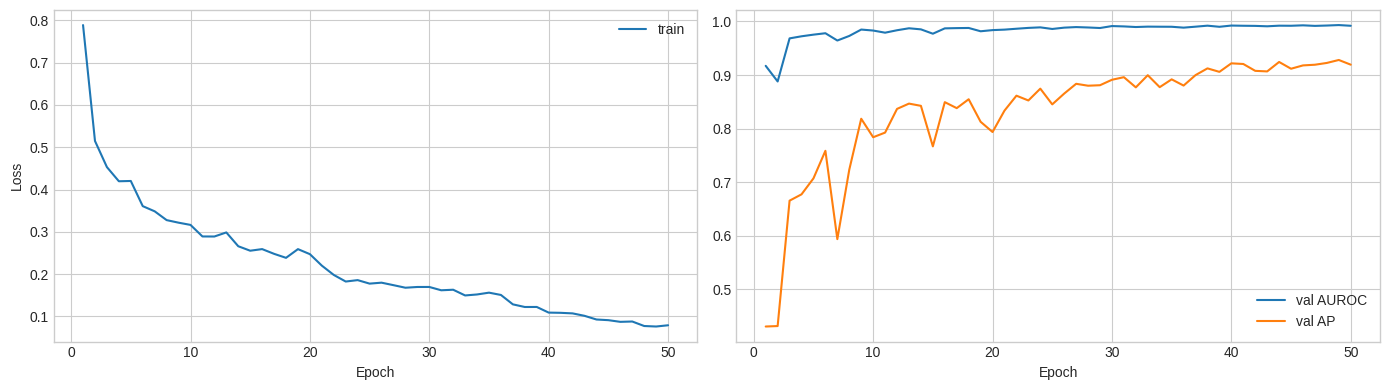

In [7]:
# Plot training curves
df = pd.DataFrame(history)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(df['epoch'], df['train_loss'], label='train')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(df['epoch'], df['val_auroc'], label='val AUROC')
ax2.plot(df['epoch'], df['val_ap'], label='val AP')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
# Threshold selection and evaluation
val_results = evaluate(model, val_loader)
test_results = evaluate(model, test_loader)

# Find best threshold with low FPR constraint
def find_threshold(labels, probs, max_fpr=TARGET_MAX_FPR):
    fpr_vals, tpr_vals, thresholds = roc_curve(labels, probs)
    # Find highest recall under FPR constraint
    valid_idx = np.where(fpr_vals <= max_fpr)[0]
    if len(valid_idx) > 0:
        best_idx = valid_idx[np.argmax(tpr_vals[valid_idx])]
        return thresholds[best_idx]
    return 0.5  # Fallback

threshold = find_threshold(val_results['labels'], val_results['probs'])

# Apply threshold
val_pred = (val_results['probs'] >= threshold).astype(int)
test_pred = (test_results['probs'] >= threshold).astype(int)

print(f'Selected threshold: {threshold:.3f}')
print(f'\nValidation Results:')
print(f'  AUROC: {val_results["auroc"]:.4f}')
print(f'  AP: {val_results["ap"]:.4f}')
print(classification_report(val_results['labels'], val_pred, target_names=CLASS_NAMES))

print(f'\nTest Results:')
print(f'  AUROC: {test_results["auroc"]:.4f}')
print(f'  AP: {test_results["ap"]:.4f}')
print(classification_report(test_results['labels'], test_pred, target_names=CLASS_NAMES))

Selected threshold: 0.957

Validation Results:
  AUROC: 0.9933
  AP: 0.9282
              precision    recall  f1-score   support

    Non-lens       0.99      1.00      0.99      2868
        Lens       0.90      0.76      0.83       173

    accuracy                           0.98      3041
   macro avg       0.94      0.88      0.91      3041
weighted avg       0.98      0.98      0.98      3041


Test Results:
  AUROC: 0.9832
  AP: 0.7777
              precision    recall  f1-score   support

    Non-lens       1.00      0.99      1.00     19455
        Lens       0.57      0.75      0.65       195

    accuracy                           0.99     19650
   macro avg       0.79      0.87      0.82     19650
weighted avg       0.99      0.99      0.99     19650



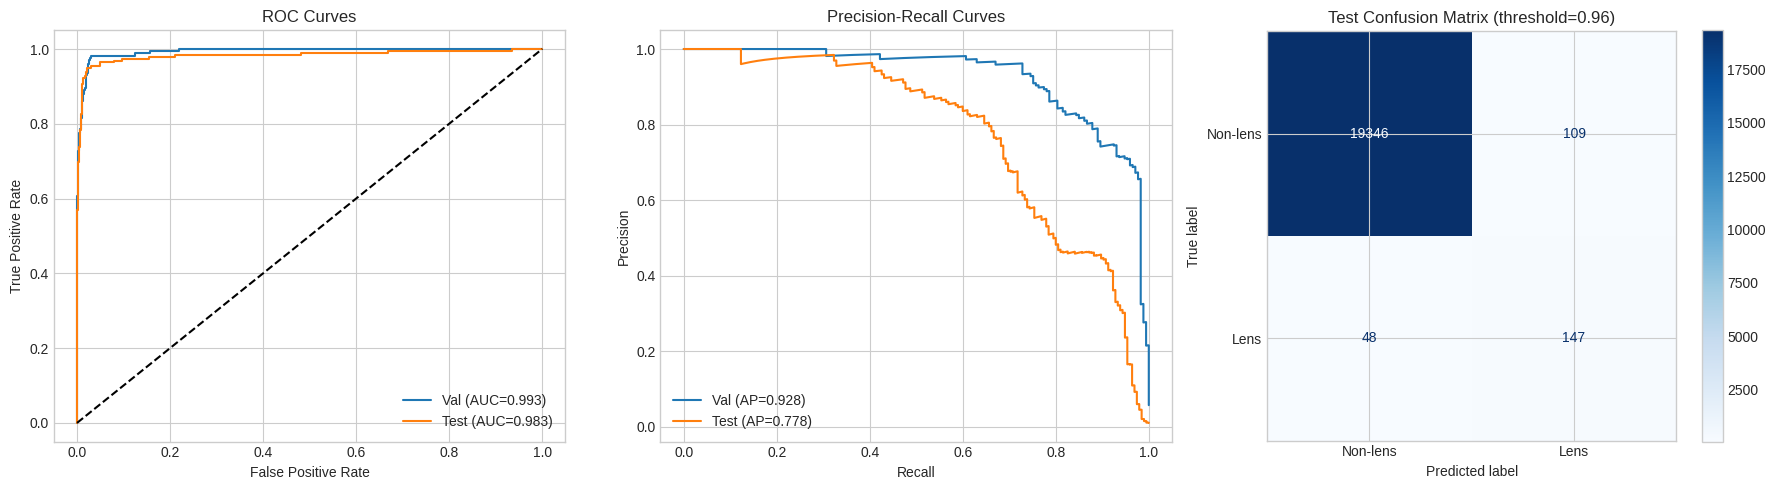

In [9]:
# ROC and PR curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
val_fpr, val_tpr, _ = roc_curve(val_results['labels'], val_results['probs'])
test_fpr, test_tpr, _ = roc_curve(test_results['labels'], test_results['probs'])
axes[0].plot(val_fpr, val_tpr, label=f'Val (AUC={val_results["auroc"]:.3f})')
axes[0].plot(test_fpr, test_tpr, label=f'Test (AUC={test_results["auroc"]:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

# PR curves
val_prec, val_rec, _ = precision_recall_curve(val_results['labels'], val_results['probs'])
test_prec, test_rec, _ = precision_recall_curve(test_results['labels'], test_results['probs'])
axes[1].plot(val_rec, val_prec, label=f'Val (AP={val_results["ap"]:.3f})')
axes[1].plot(test_rec, test_prec, label=f'Test (AP={test_results["ap"]:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

# Confusion matrix
test_cm = confusion_matrix(test_results['labels'], test_pred)
ConfusionMatrixDisplay(test_cm, display_labels=CLASS_NAMES).plot(ax=axes[2], cmap='Blues')
axes[2].set_title(f'Test Confusion Matrix (threshold={threshold:.2f})')

plt.tight_layout()
plt.show()